# Lecture 7: Metric learning

In this exercise, I've implemented metric learning ML algorithms using the MagnaTagATune dataset, and evaluated the quality of the embeddings by plotting their position in latent space. 

## Contents of the Notebook:
- **Step 1:** Load MagnaTagATune Dataset
- **Step 2:** Define the CNN model, Feature Extraction, and Augmentation classes
- **Step 3:** Train a CNN with the InfoNCE loss and Triplet Loss 
- **Step 4:** Perform clustering of the validation set

In [1]:

# !pip install torch
# !pip install torchcodec
# !pip install datasets[audio]==3
# !pip install tqdm
# !pip install scikit-learn
# !pip install matplotlib
# !pip install torch-audiomentations

# Added another pip install 
# !pip install umap-learn

In [ ]:
import random
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import umap.umap_ as umap #changed the way this was installed 

# AP - newly added imports
import os
import torchaudio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings
import torchaudio.functional as ta_F
import torchaudio.transforms as T
import random


from datasets import load_dataset
from sklearn.preprocessing import OneHotEncoder
from torch.utils.data import DataLoader, Dataset
from torchaudio.transforms import MelSpectrogram, Resample
from torch_audiomentations import (
    Compose,
    Gain,
    PolarityInversion,
    AddBackgroundNoise,
    AddColoredNoise,
    BandStopFilter,
    ApplyImpulseResponse,
    PitchShift,
    LowPassFilter,
)
from tqdm import tqdm

# AP - newly added imports
from torch.utils.data import Dataset, DataLoader

device = "cpu"  # Configure depending on the runtime

/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venvpy311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Step 1: Load MagnaTagATune Dataset

Compared to prior lab's I've altered the MagnaTagATune class to crop audio based on target duration and generate take **2 views** or two clips from the same audio file, each 1 second apart from each other meaning they have some overlap and can used to train the model to recognize similar songs (i.e. a positive point) vs. something that's from another song and therefore a negative point. 

In addition to cropping the audio, I've added an **padding function** to ensure all clips are at least as long as the desired duration. `'view 1'` and `'view 2'` will be referenced later in the notebook as callable indexes of the class item. 

In [4]:
# ==========================================================
# Load MagnaTagATune Annotations and Remove Corrupt Files
# ==========================================================

data_root = '../Lab 5'
mp3_root = '../Lab 5/mp3'

annotations = pd.read_csv(os.path.join(data_root, 'annotations_final.csv'), delimiter='\t')

# Identify empty MP3 files
empty_files = [
    file for file in annotations.mp3_path.values
    if file.lower().endswith('.mp3')
    and os.path.exists(os.path.join(mp3_root, file))
    and os.path.getsize(os.path.join(mp3_root, file)) == 0
]

print(f"Empty_files:\n{empty_files}")
print(len(annotations))

# Drop empty/corrupt files from the list of annotations
annotations = annotations[~annotations['mp3_path'].isin(empty_files)].reset_index(drop=True)

# Saving this version of annotations prior to genre filtering
all_annotations = annotations

print(len(annotations))

Empty_files:
['6/norine_braun-now_and_zen-08-gently-117-146.mp3', '8/jacob_heringman-josquin_des_prez_lute_settings-19-gintzler__pater_noster-204-233.mp3', '9/american_baroque-dances_and_suites_of_rameau_and_couperin-25-le_petit_rien_xiveme_ordre_couperin-88-117.mp3']
25863
25860


In [5]:
# ==========================================================
# Filter Annotations for Only Relevant Genre Info
# ==========================================================

song_info = pd.read_csv(os.path.join(data_root, 'song_info.csv'), on_bad_lines='skip').fillna('')

# Splitting and cleaning genre information
def split_genres(col):
    genres = [g.strip().lower() for i in song_info[col].values for g in i.split(',') if g.strip()]
    return list(set(genres))

mp3_genre = split_genres('mp3genre')
magnatunegenres = split_genres('magnatunegenres')

# Aggregate a "complete" list of genres from both columns into a final list of all genres
all_genres =list(set(mp3_genre + magnatunegenres))

# Match the column names in Annotations_File.csv with the list of genres we've compiled above
annotations_labels = annotations.columns.values
genre_columns = [i for i in annotations_labels if i in all_genres]

# List of columns we will want to pull from the annotations_file.csv file
selected_columns = ['clip_id'] + genre_columns + ['mp3_path']
annotations = annotations[selected_columns]

# Remove rows that do not have any genre labels
annotations = annotations[~(annotations[genre_columns].sum(axis=1) == 0)]

annotations['track_folder'] = [i[0] for i in annotations['mp3_path'].str.split('/')]

# Print the removed columns to visually confirm they are not genre related
kept_columns = selected_columns + ['track_folder']
removed_columns = [col for col in all_annotations if col not in kept_columns]
print(f"Total original columns: {len(all_annotations)}")
print(f"Columns kept: {len(kept_columns)}")
print(f"Columns removed: {len(removed_columns)}")
print(f"\nRemoved columns:\n{removed_columns}")

Total original columns: 25860
Columns kept: 36
Columns removed: 155

Removed columns:
['no voice', 'singer', 'duet', 'plucking', 'bongos', 'female singing', 'clasical', 'sitar', 'chorus', 'female opera', 'male vocal', 'vocals', 'clarinet', 'heavy', 'silence', 'beats', 'men', 'woodwind', 'funky', 'no strings', 'chimes', 'foreign', 'no piano', 'horns', 'female', 'no voices', 'soft rock', 'eerie', 'spacey', 'quiet', 'no beat', 'banjo', 'electric', 'solo', 'violins', 'female voice', 'wind', 'happy', 'synth', 'no singing', 'middle eastern', 'trumpet', 'percussion', 'drum', 'airy', 'voice', 'repetitive', 'birds', 'space', 'strings', 'bass', 'harpsicord', 'male voice', 'girl', 'keyboard', 'acoustic', 'loud', 'classic', 'string', 'drums', 'electronic', 'not classical', 'chanting', 'no violin', 'not rock', 'no guitar', 'organ', 'no vocal', 'talking', 'weird', 'soprano', 'fast', 'acoustic guitar', 'electric guitar', 'male singer', 'man singing', 'classical guitar', 'violin', 'electro', 'tribal',

In [6]:
# ==========================================================
# Splitting Dataset Between Training / Validation / Testing
# ==========================================================

trainning_folders = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b' ]
val_folders = ['c']
test_folders = ['d','e','f']

train_split = annotations[annotations['track_folder'].isin(trainning_folders)]
val_split = annotations[annotations['track_folder'].isin(val_folders)]
test_split = annotations[annotations['track_folder'].isin(test_folders)]

In [7]:

# convert the train_split dataframe into a numpy array and pull only genre related columns (i.e. the labels)
y_train = train_split[train_split.columns[1:-2]].values
y_val = val_split[val_split.columns[1:-2]].values
y_test = test_split[test_split.columns[1:-2]].values

# convert the train_split dataframe into a numpy array and pull only metadata to identify the song (i.e. 'clip_id' and 'mp3_path')
X_train = train_split[[train_split.columns[0],train_split.columns[-2]]].values
X_val = val_split[[val_split.columns[0],val_split.columns[-2]]].values
X_test = test_split[[test_split.columns[0],test_split.columns[-2]]].values

print('X_train Shape:', X_train.shape)
print("y_train Shape:", y_train.shape)


X_train Shape: (13033, 2)
y_train Shape: (13033, 33)


In [ ]:
# ================================
# Establishing Data Loading Class
# ================================

class MagnaTagATune(Dataset):
    def __init__(self, file_paths_and_ids, labels, target_duration=3.0, sample_rate=16000, transform=None, root_dir='./'):
        
        self.sample_rate = sample_rate # Standardized sample rate
        self.audio_duration = target_duration
        self.file_paths_and_ids = file_paths_and_ids # This contains the X_train/val/test ['clip_id', 'mp3_path'], ...]
        self.target_samples = max(int(target_duration * sample_rate), 1024)
        self.root_dir = root_dir
        self.transform = transform
        self.n_samples = int(sample_rate * target_duration)
        self.max_separation = 1  # maximum separation between views
        
        self.audio = {}
        self.labels = {}
        self.tids = []
        # self.audio_files = {}

        # Debug: basic info
        print(f"\nInitializing MagnaTagATune dataset with {len(file_paths_and_ids)} tracks.")
        print(f"Sample rate: {self.sample_rate}, Target samples: {self.target_samples}")

        # match labels with clip id for easier debugging
        for idx, (clip_id, relative_path) in enumerate(file_paths_and_ids):
            if not relative_path.startswith('mp3/'):
                relative_path = os.path.join('mp3', relative_path)
            
            path = os.path.join(root_dir, relative_path)
            # self.audio_files[idx] = os.path.join(root_dir, relative_path)
            # self.labels[idx] = torch.tensor(labels[idx], dtype=torch.float32)  # <-- use encoded

            try:
                x, sr = torchaudio.load(path)
            except Exception as e:
                print(f"Failed to load {path}: {e}")
                raise
                
            # Resample if needed 
            if sr != sample_rate:
                x = torchaudio.functional.resample(x, sr, sample_rate)

            x = x.squeeze(0)       # convert (1, T) → (T,)
            self.audio[idx] = x
            self.labels[idx] = torch.tensor(labels[idx], dtype=torch.float32)
            self.tids.append(idx)


    def __len__(self):
        return len(self.tids)

    def _crop_or_pad(self, waveform):
        num_samples = waveform.shape[-1]
        if num_samples > self.target_samples:
            # Random crop during training, center crop for evaluation (though this dataset uses it for both)
            start = random.randint(0, num_samples - self.target_samples)
            waveform = waveform[:, start:start + self.target_samples]
        elif num_samples < self.target_samples:
            # Pad with zeros at the end
            pad_amount = self.target_samples - num_samples
            waveform = torch.nn.functional.pad(waveform, (0, pad_amount))
        return waveform

    def get_start_end_indices(self, min_pos, max_pos):
        start = random.randint(min_pos, max_pos - self.n_samples)
        end = start + self.n_samples
        return start, end
    
    def __getitem__(self, idx):
        tid = self.tids[idx]
        audio_full = self.audio[tid]
        label = self.labels[tid]
        
        length = audio_full.shape[0]
        
        # ---- View 1: totally random crop -----
        min_pos, max_pos = 0, length
        start, end = self.get_start_end_indices(min_pos, max_pos)
        view_1 = audio_full[start:end]
        
        # --- View 2: constrained (+_ max_separation seconds) ----
        shift = int(self.max_separation * self.sample_rate)
        min_pos = max(0, start - shift)
        max_pos = min(length - self.n_samples, start + shift)
        
        start2, end2 = self.get_start_end_indices(min_pos, max_pos + self.n_samples)
        view_2 = audio_full[start2:end2]

        # --- Center padded audio ---
        audio = audio_full
        if audio.shape[0] < self.n_samples:
            pad = self.n_samples - audio.shape[0]
            audio = torch.nn.functional.pad(audio, (0, pad))
        else:
            audio = audio[:self.n_samples]

        return {
            "view_1": view_1,
            "view_2": view_2,
            "audio": audio,
            "labels": label,
        }


In [9]:
# ==================================
# Implement Loading Data Functions
# ==================================

batch_size = 128 
target_duration = 3.0
sample_rate = 16000

train_transforms=None
val_transforms=None

# Instantiate the dataset using the corrected class
train_dataset = MagnaTagATune(X_train, y_train, target_duration=target_duration, transform=train_transforms, root_dir='../Lab 5')
val_dataset = MagnaTagATune(X_val, y_val,target_duration=target_duration, transform=val_transforms,root_dir='../Lab 5')

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=False)

first_batch = next(iter(val_loader))




Initializing MagnaTagATune dataset with 13033 tracks.
Sample rate: 16000, Target samples: 48000

Initializing MagnaTagATune dataset with 1337 tracks.
Sample rate: 16000, Target samples: 48000


# Step 2: Define the CNN model, Feature Extraction, and Augmentation classes

To set up the experiment we must first define a simple CNN architecture suitable for music autotagging, applying augmentations to the audio, and extracting features (MelSpectrograms) to be fed into the model. The CNN consists of three convolutional layers with increasing channel depth, each followed by ReLU activation, batch normalization, and max pooling to extract higher-level spectral-temporal features at each layer from the input audio features. After the convolutional stack, the model flattens the learned feature maps and passes them through two fully connected layers, combining the extracted features and output class predictions for genre classification. 

In this section, I've re-implemented the `FeatureExtractor` class in a more explicit manner in order to improve model training efficiency. The output is ultimately the same the original implementation (commented below), but in this implementation the mel projection runs on the same device as the input. 

The `AugmentationChain` class applies a sequence of transformations to each audio sample with a probability of 75%. These augmentations artificially increase the diversity of the dataset by simulating real-world variations in recordings, helping the CNN learn features that are more robust, genre-relevant, and not overly sensitive to superficial changes. The augmentations include:

- `Gain` adjusts the overall loudness of the waveform by scaling its amplitude. This prevents the model from relying on volume-related cues, which can differ widely due to production decisions rather than genre. Instead the model is pushed to learn features like timbre, rhythmic patterns, and instrumentation that truly differentiate genres.

- `BandStopFilter` removes energy from a narrow band of frequencies, related to the idea of frequency masking which aligns the audio with how human hearing perceives frequencies (which is inherently non-linear). This can aid in preventing overfitting to specific frequency relationships, and make the model more stable around audios with small portions of frequency spectrum missing or altered. The model will focus more on holistic spectral patterns typical of each genre rather than narrow frequency artifacts. 

- `Pitchshift` changes the pitch of the audio by a small amount without altering tempo. This augmentation ensures the model does not generalize based on tuning or the key of a song since this is not an indicator of genre. 

- `AddColoredNoise` injects noise with different spectral shapes (i.e. pink, brown, white noise). Real music recordings can include background noise and other imperfections / artifacts especially if the recording was taken during a live performance. By adding noise, the model is encouraged to rely on the more genre-related spectral characteristics instead of the presence of noise. 

-`LowPassFilter` removes high-frequency content above a learned cutoff. Low-pass filtering simulates natural compression which occurs when listening to audio in different settings, like having distance from the source or listening from low-quality speakers. This forces the network to learn mid-band and low-band features that usually remain as stronger indicators of genre even when the audio has been degraded. 

By exposing the CNN to these variations during training, the model becomes more invariant to irrelevant differences and develops a deeper understanding of genre-driven acoustic patterns. This reduces overfitting and improves generalization on unseen tracks.


In [10]:
class FeatureExtractor(nn.Module):
    def __init__(self, n_mels=64, n_fft=1024, hop_length=512):
        super().__init__()
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.mel_scale = torchaudio.transforms.MelScale(
            n_mels=n_mels,
            sample_rate=16000,
            n_stft=n_fft // 2 + 1,
        )

    def forward(self, x):
        # x: (batch, time)
        x_stft = torch.stft(
            x,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            return_complex=True,
        )
        magnitude = x_stft.abs()

        # Mel projection runs on **same device as input**
        mel = self.mel_scale(magnitude)
        mel = torch.log10(1 + 1000 * mel)
        return mel

In [ ]:
# =====================================
# Original Feature Extractor Function
# =====================================

# Feature extractor. Using mel-spectrogram

# class FeatureExtractor(nn.Module):
#     def __init__(self, **kwargs):
#         super().__init__()
#         self.melspectrogram = MelSpectrogram(**kwargs)

#     def forward(self, x):
#         x = self.melspectrogram(x)
#         x = torch.log10(1 + 1000 * x)  # Log-compression
#         return x

In [ ]:
class AugmentationChain(nn.Module):
    """Add a number of audio augmentaitons with probability p."""

    p = 0.75
    sr = 16000
    def __init__(self, **kwargs):
        super().__init__()
        self.chain = Compose(
            transforms=[
                Gain(p=self.p, output_type='tensor'),
                BandStopFilter(sample_rate=self.sr, p=self.p, output_type='tensor'),
                PitchShift(p=self.p, sample_rate=self.sr, output_type='tensor'),
                AddColoredNoise(p=self.p, output_type='tensor'),
                LowPassFilter(p=self.p, sample_rate=self.sr, min_cutoff_freq=400, output_type='tensor',),
            ]
            , output_type='tensor'
        )

    def forward(self, audio):
        return self.chain(audio.unsqueeze(1)).squeeze(1)   ## why squeeze then unsqueeze? What does the extra dimension do?

/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venvpy311/lib/python3.11/site-packages/torch/functional.py:681: UserWarning: A window was not provided. A rectangular window will be applied,which is known to cause spectral leakage. Other windows such as torch.hann_window or torch.hamming_window are recommended to reduce spectral leakage.To suppress this warning and use a rectangular window, explicitly set `window=torch.ones(n_fft, device=<device>)`. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/SpectralOps.cpp:842.)
  return _VF.stft(  # type: ignore[attr-defined]


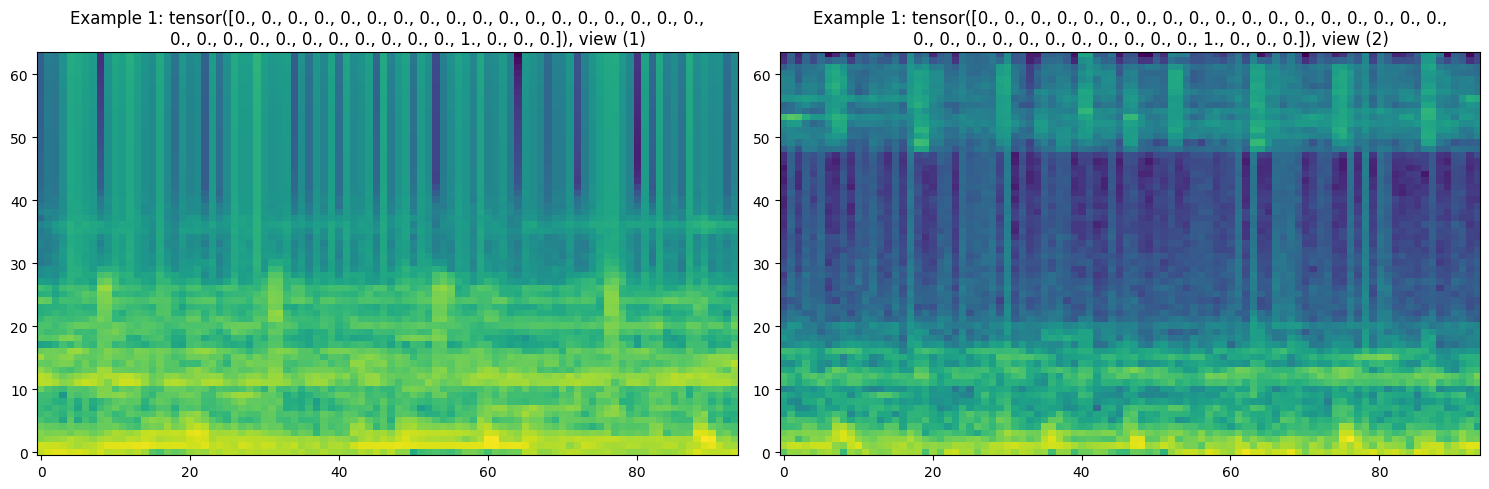

In [12]:
feature_extractor = FeatureExtractor(n_mels=64, n_fft=1024).to(device)
augmentation_chain = AugmentationChain().to(device)

# Fetch a batch of data
batch = next(iter(val_loader))

# Move batch tensors onto the right device
view_1 = batch["view_1"].to(device)
view_2 = batch["view_2"].to(device)

# Augmentations must run on CPU → move to CPU temporarily
aug_view_1 = augmentation_chain(view_1.cpu())
aug_view_2 = augmentation_chain(view_2.cpu())

# Now send augmented views back to GPU
aug_view_1 = aug_view_1.to(device)
aug_view_2 = aug_view_2.to(device)

# Feature extraction on GPU
mel_specs_1 = feature_extractor(aug_view_1)
mel_specs_2 = feature_extractor(aug_view_2)

# Move to CPU before numpy()
mel_specs_1 = mel_specs_1.detach().cpu().numpy()
mel_specs_2 = mel_specs_2.detach().cpu().numpy()

# mel_specs_1 = feature_extractor(augmentation_chain(batch["view_1"])).numpy()
# mel_specs_2 = feature_extractor(augmentation_chain(batch["view_2"])).detach().numpy()

# Visualize the first three mel-spectrograms in the batch
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for i, mels in enumerate([mel_specs_1, mel_specs_2]):
    axes[i].imshow(mels[0], aspect="auto", origin="lower")
    axes[i].set_title(f"Example {0+1}: {batch['labels'][0]}, view ({i+1})")
plt.tight_layout()
plt.show()

In [13]:
n_classes = len(set(val_dataset.labels.values()))

batch = next(iter(val_loader))
mels = feature_extractor(batch["view_1"].to(device)).to(device)

print("Mel-spectrogram shape:", mels.shape)
print("Number of classes:", n_classes)

Mel-spectrogram shape: torch.Size([128, 64, 94])
Number of classes: 1337


In [21]:
class CNN(nn.Module):
    def __init__(
        self,
        kernel_size: int = 3,
        pooling_size: int = 4,
        dense_size: int = 64,
        output_size: int = 10,
    ):
        super().__init__()
        self.dense_size = dense_size
        self.conv1 = nn.Conv2d(
            1, dense_size // 4, kernel_size=kernel_size, stride=1, padding=1
        )
        self.conv2 = nn.Conv2d(
            dense_size // 4, dense_size // 2, kernel_size=kernel_size, stride=1, padding=1
        )
        self.conv3 = nn.Conv2d(
            dense_size // 2, dense_size, kernel_size=kernel_size, stride=1, padding=1
        )

        self.bn1 = nn.BatchNorm2d(dense_size // 4)
        self.bn2 = nn.BatchNorm2d(dense_size // 2)
        self.bn3 = nn.BatchNorm2d(dense_size)

        self.pool = nn.MaxPool2d(kernel_size=pooling_size, stride=pooling_size)
        self.fc1 = nn.Linear(dense_size, dense_size)
        self.fc2 = nn.Linear(dense_size, output_size)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.bn1(self.pool(F.relu(self.conv1(x))))
        x = self.bn2(self.pool(F.relu(self.conv2(x))))
        x = self.bn3(self.pool(F.relu(self.conv3(x))))

        x = x.view(-1, self.dense_size)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Step 3: Train a CNN with the InfoNCE loss and Triplet Loss 

In this section, I define the `train` function which will be used by the model on two metric-learning loss functions, `triplet loss` and `InfoNCE` (also defined in this section). 

- `triplet loss` is a loss function which calculates two distances, one between an anchor sample to a positive sample (one of the same genre) and another between the anchor and a negative sample (randomly chosen from the batch). This function incentivizes when positive points are closer to the anchor than negative points by at least one margin (margin=1.0 in this implementation). This encourages clustering of samples from the same genre, and improves the separability of genres in the embedding space, improving classification performance. 

- `InfoNCE` is a contrastive loss function which encourages paired embeddings from the same audio to be highly similar and push them away from other samples in the batch. After normalizing the embeddings between the two samples, it measures the similarity twice between the two samples through matrix multiplication, (math is done twice and switches which point is the anchor vs the positive point). Then cross entropy loss is calculated on both of the similarity values. This function trains the model to learn features of the audio that are augmentation-invariant. By pulling together different augmented views of the same track and repelling other tracks, the network forms a meaningful latent space where songs in similar genres naturally cluster. 

Additionally, I incorporated **checkpoints** to retrieve model weights, **early stop** with patience = 5 epochs of no improvement on validation loss, as well as `torch.no_grad()` in the `train` function to avoid the vanishing gradient effect.

In [ ]:
# Training loop
def train(
    model,
    loss_fn,
    n_epochs=3,
    lr=0.001,
    device="mps",
    augment=True,
    batch_size=64,
    patience=5,
    checkpoint_path="checkpoints/best_model.pt"
):
    # Use Adam optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Create checkpoint directory
    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    best_val_loss = float("inf")
    patience_counter = 0 

    for epoch in range(n_epochs):
        
        # ----------------------------
        # Training loop
        # ----------------------------
        
        model.train()
        total_loss = 0
        
        for batch in train_loader:
            x1 = batch["view_1"].to(device)
            x2 = batch["view_2"].to(device)

            if augment:
              x1 = augmentation_chain(x1)
              x2 = augmentation_chain(x2)

            x1 = feature_extractor(x1)
            x2 = feature_extractor(x2)

            # Forward step for both augmentations
            z1 = model(x1)
            z2 = model(x2)
            loss = loss_fn(z1, z2)
            total_loss += loss.item()

            # Backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
        train_loss = total_loss / len(train_loader)
        
        # -------------------------------------------------------------
        # Validation loop (still using cross-entropy for evaluation)
        # -------------------------------------------------------------
        
        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            
            for batch in val_loader:
                x1 = batch["view_1"].to(device)
                x2 = batch["view_2"].to(device)

                if augment:
                    x1 = augmentation_chain(x1)
                    x2 = augmentation_chain(x2)

                x1 = feature_extractor(x1)
                x2 = feature_extractor(x2)

                # Forward step for both augmentations
                z1 = model(x1)
                z2 = model(x2)
                loss = loss_fn(z1, z2)

                total_val_loss += loss.item()

        val_loss = total_val_loss / len(val_loader)


        # ----------------------------------------
        # Logging 
        # ----------------------------------------
        print(
            f"Epoch [{epoch + 1}/{n_epochs}], "
            + f"Train loss: {train_loss:.4f}, "
            + f"Val loss: {val_loss:.4f}"
        )
        
        # ============================
        # CHECKPOINT + EARLY STOPPING
        # ============================
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0

            torch.save(model.state_dict(), checkpoint_path)
            print(f"  ➤ New best model saved to {checkpoint_path}")

        else:
            patience_counter += 1
            print(f"  Patience: {patience_counter}/{patience}")

            if patience_counter >= patience:
                print("\nEarly stopping triggered.\n")
                break

    print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")


In [16]:
def triplet_loss(anchor, positive, margin=1.0):
    # Pick a random negative from the batch (next sample)
    negative = torch.roll(positive, 1, dims=0)

    distance_positive = (anchor - positive).pow(2).sum(1)
    distance_negative = (anchor - negative).pow(2).sum(1)

    losses = F.relu(distance_positive - distance_negative + margin)
    return losses.mean()

In [17]:
def InfoNCE(z_1, z_2, temp=0.5):
    # Normalize the embeddings
    z_1 = F.normalize(z_1, dim=1)
    z_2 = F.normalize(z_2, dim=1)

    # Similarity matrices
    sim_12 = torch.matmul(z_1, z_2.T)  # z1 as anchor, z2 as candidates
    sim_21 = torch.matmul(z_2, z_1.T)  # z2 as anchor, z1 as candidates

    # Labels: each sample i should match its own pair i
    labels = torch.arange(sim_12.size(0)).to(sim_12.device)

    # InfoNCE losses (both directions)
    loss_12 = F.cross_entropy(sim_12 / temp, labels)
    loss_21 = F.cross_entropy(sim_21 / temp, labels)

    # Symmetric SimCLR loss
    return 0.5 * (loss_12 + loss_21)

# Step 4: Perform clustering of the validation set

In order to evaluate how well each model learns meaningful representations of genres, I trained the models with 20 epochs and projected their final latent spaces using UMAP. experimented with different visualization approaches, specifically adapting the template code to handle the multi-label nature of the dataset, so that each plot clearly highlighted the distribution of samples associated with each genre label. 

## Plot 1: Per-Label Visualizations
Across the per-label UMAP plots, most genres did not show strong, well-defined clusters, but a few like **opera**, **medieval**, and **lute** displayed noticeably tighter groupings where samples gravitated towards similar regions of the latent space. In contrast, labels with a large number of samples, such as **guitar**, were more diffused across space and struggled to cluster into one area in the map. This is likely because highly populated labels contain more stylistic and acoustic diversity, making it harder for the model to form a compact cluster compared to labels with fewer, more homogeneous samples. 

When comparing results for **guitar** between the model using triplet loss (`cnn_tl`) and InfoNCE loss (`cnn`), the InfoNCE UMAP plots generally show more concentrated groupings of guitar samples. Overall, labels tended to appear in similar regions across both models (for example: classical often appearing on the right side of the UMAP space), suggesting that both loss functions encouraged the models to learn comparable genre-related characteristics. Compared to the baseline CNN model, both **triplet loss** and **InfoNCE** produced more coherent clusters of same-genre samples, indicating improved representation learning.

## Plot 2: Hard Rock vs. World 

To further examine how well the models separate distinct genres, I selected **hard rock** and **world**, two non-overlapping genres, and compared how each model positioned them in the latent space. Surprisingly, the baseline CNN appeared to separate these two genres the most cleanly in the UMAP projection. The metric-learning models occasionally placed samples from these two genres closer together, but some samples of **world** samples were diffused across the latent space. This suggests that for these particular labels, the loss function may not have converged to representations that maximize the separable features of the audio or recognized similarities between songs of the same genre. 

## Plot 3: Multi-Genre Comparison

Because labels with small sample counts could have introduced biases that complicate clustering, I broadened the analysis to 13 non-overlapping genres. Across all the models, it is hard to see true separations between genres and draw boundary lines. Nevertheless, we do see most points have another sample of the same label nearby, evidence that the metric-learning objectives generally encouraged positive pairs to stay close in the latent space, even if the boundaries between genres were not sharply defined.


In [18]:
# Extract embeddings for the validation set
def plot_val_embeddings(model, device="cuda"):
    model.eval()
    embeddings = []
    natural_labels = []

    model.to(device)
    feature_extractor.to(device)
    
    with torch.no_grad():
        for batch in val_loader:

            audio_1 = batch["view_1"].to(device)
            labels = batch["labels"].to(device)

            # Extract embeddings from view 1 (or view 2, or both)
            x = feature_extractor(audio_1)
            z = model(x)
            embeddings.append(z.cpu().numpy())
            natural_labels.append(labels.cpu().numpy())

    embeddings = np.concatenate(embeddings, axis=0)
    natural_labels = np.concatenate(natural_labels, axis=0)
    Y = np.vstack(natural_labels)  

    label_names = annotations.columns[1:-2]

    print(f"Embeddings shape: {embeddings.shape}")
    print(f"Binary label matrix shape: {Y.shape}")
    print(f"Number of unique labels: {len(label_names)}")
    print(f"Label names: {label_names[:10]}...")  # Show first 10
    print(f"Example label vector (first sample): {Y[0]}")

    # ========================================
    # Perform UMAP Dimensionality Reduction
    # ========================================
    
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=25,
        min_dist=0.1,
        metric='euclidean',
        random_state=42
    )
    umap_embeddings = reducer.fit_transform(embeddings)
    print(f"UMAP embeddings shape: {umap_embeddings.shape}")

    # ========================================
    # Visualize Each Label Separately
    # ========================================
    
    # Convert multi-hot labels to a single index per sample
    label_indices = np.argmax(Y, axis=1)
    unique_labels = np.arange(Y.shape[1])
    cmap = matplotlib.cm.get_cmap("tab10", len(unique_labels))


    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        umap_embeddings[:, 0],
        umap_embeddings[:, 1],
        c=label_indices,
        cmap=cmap,
    )

    handles, _ = scatter.legend_elements(prop="colors", num=len(unique_labels))
    plt.legend(handles, unique_labels, title="Labels")

    plt.title("UMAP of Audio Embeddings")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.show()
    
    
    # ========================================
    # Visualize Each Label Separately
    # ========================================

    num_labels = len(label_names)
    cols = 4
    rows = int(np.ceil(num_labels / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = axes.flatten()  # flatten to 1D for easy indexing


    for i, label_name in enumerate(label_names):
        ax = axes[i]
        
        # Boolean mask for samples that contain this label
        mask = Y[:, i].astype(bool)
        num_samples_with_label = mask.sum()
        
        # Plot all points faintly in background
        ax.scatter(
            umap_embeddings[:, 0], umap_embeddings[:, 1],
            c='lightgray', s=3, alpha=0.2
        )
        
        # Highlight only the samples with this label
        ax.scatter(
            umap_embeddings[mask, 0], umap_embeddings[mask, 1],
            c='red', s=6, alpha=0.9
        )
        
        ax.set_title(f"{label_name} (n={num_samples_with_label})", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

    # Hide unused axes if any
    for j in range(num_labels, len(axes)):
        axes[j].axis("off")

    fig.suptitle("UMAP Embedding - Per-Label Visualization", fontsize=16, y=1.00)
    plt.tight_layout()
    plt.show()


In [19]:
x = torch.randn(4, 16000).to(device)
mel = feature_extractor(x)
print("Mel device:", mel.device)


Mel device: cpu


## Plot 1: Per-Label Visualizations

CNN Trainable parameters: 31840
Embeddings shape: (1337, 64)
Binary label matrix shape: (1337, 33)
Number of unique labels: 33
Label names: Index(['hard rock', 'world', 'harpsichord', 'classical', 'jazz', 'guitar',
       'folk', 'ambient', 'new age', 'funk'],
      dtype='object')...
Example label vector (first sample): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 1. 0. 0. 0.]


/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venvpy311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embeddings shape: (1337, 2)


/var/folders/r4/z65_5ryn59z3_3lyzgvxdcm40000gn/T/ipykernel_4270/1946034281.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap("tab10", len(unique_labels))


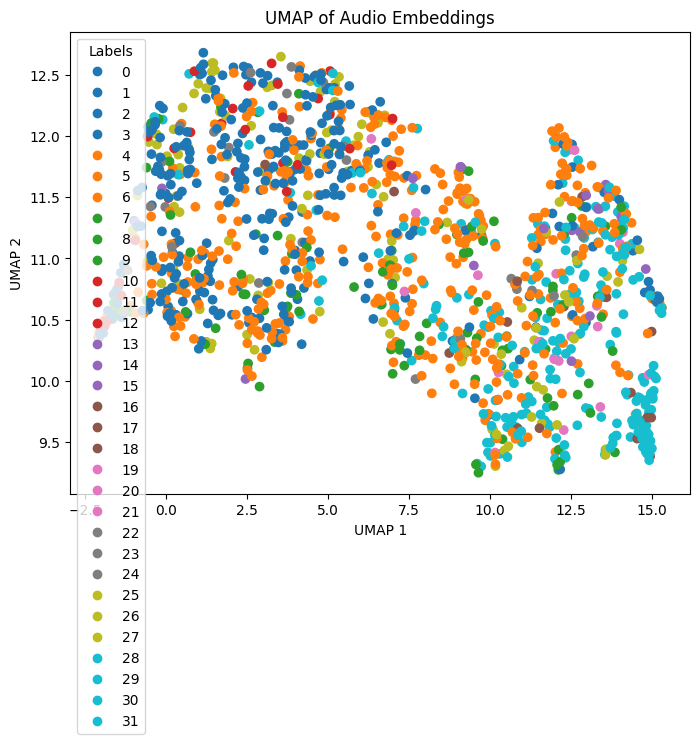

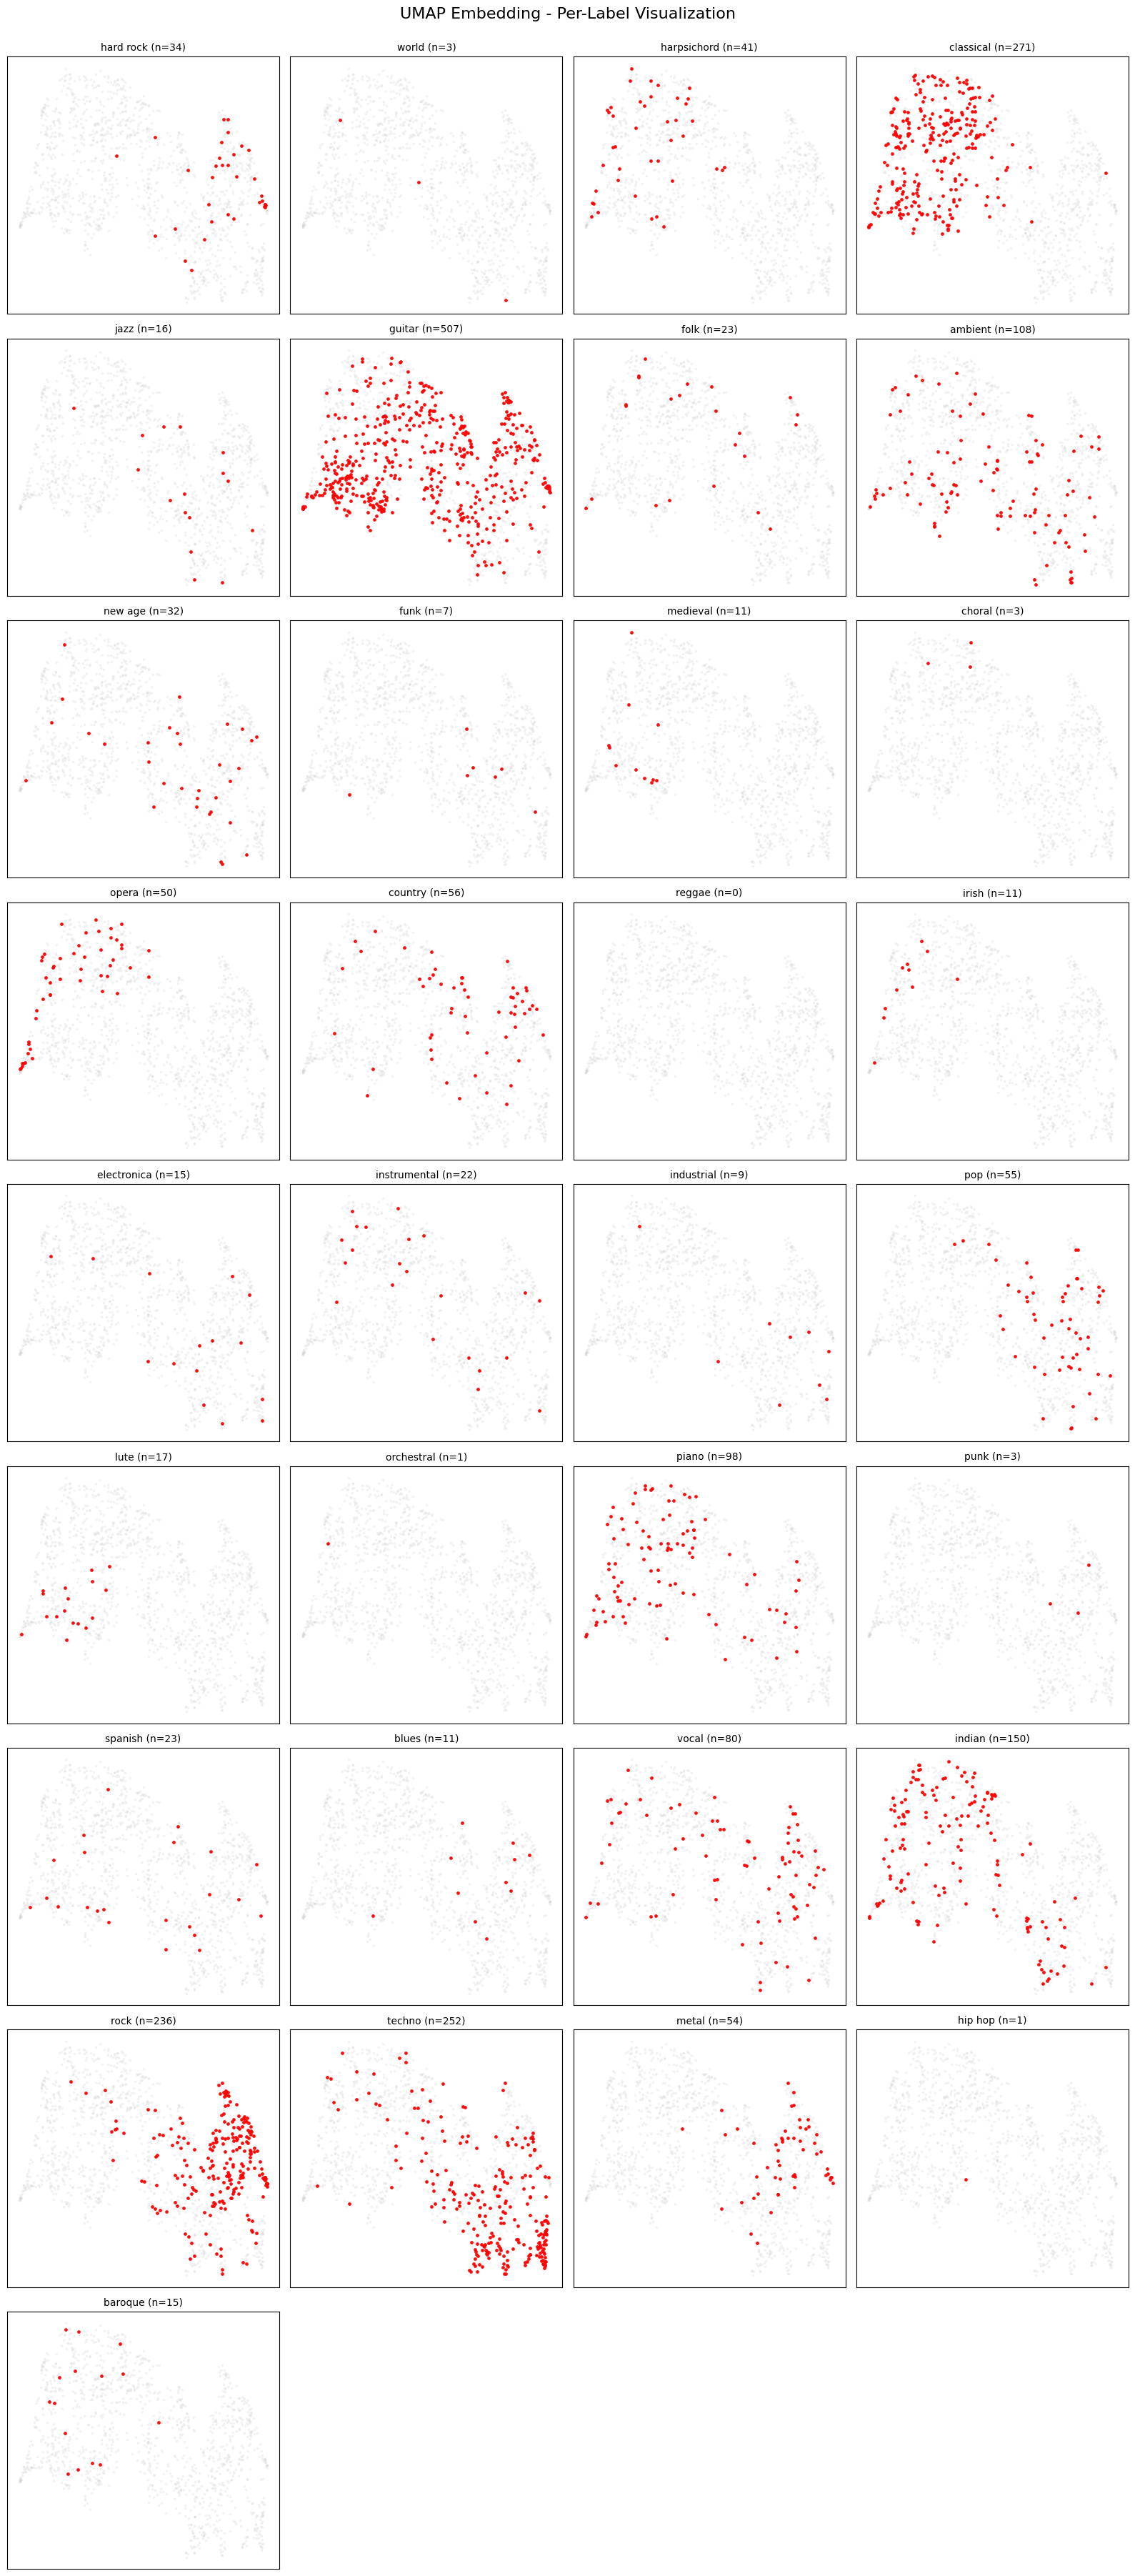

In [23]:
cnn_baseline = CNN(dense_size=64, output_size=64).to(device)

num_params = sum(p.numel() for p in cnn_baseline.parameters() if p.requires_grad)
print(f"CNN Trainable parameters: {num_params}")

plot_val_embeddings(cnn_baseline, device=device)


Training model with the triplet loss
Epoch [1/20], Train loss: 0.5301, Val loss: 0.7663
  ➤ New best model saved to checkpoints/cnn_tl.pt
Epoch [2/20], Train loss: 0.4305, Val loss: 0.7339
  ➤ New best model saved to checkpoints/cnn_tl.pt
Epoch [3/20], Train loss: 0.3905, Val loss: 0.7315
  ➤ New best model saved to checkpoints/cnn_tl.pt
Epoch [4/20], Train loss: 0.3658, Val loss: 0.6923
  ➤ New best model saved to checkpoints/cnn_tl.pt
Epoch [5/20], Train loss: 0.3310, Val loss: 0.6876
  ➤ New best model saved to checkpoints/cnn_tl.pt
Epoch [6/20], Train loss: 0.3284, Val loss: 0.6815
  ➤ New best model saved to checkpoints/cnn_tl.pt
Epoch [7/20], Train loss: 0.3009, Val loss: 0.6544
  ➤ New best model saved to checkpoints/cnn_tl.pt
Epoch [8/20], Train loss: 0.2938, Val loss: 0.7051
  Patience: 1/5
Epoch [9/20], Train loss: 0.2654, Val loss: 0.5677
  ➤ New best model saved to checkpoints/cnn_tl.pt
Epoch [10/20], Train loss: 0.2603, Val loss: 0.6251
  Patience: 1/5
Epoch [11/20], Trai

/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venvpy311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embeddings shape: (1337, 2)


/var/folders/r4/z65_5ryn59z3_3lyzgvxdcm40000gn/T/ipykernel_92956/1946034281.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap("tab10", len(unique_labels))


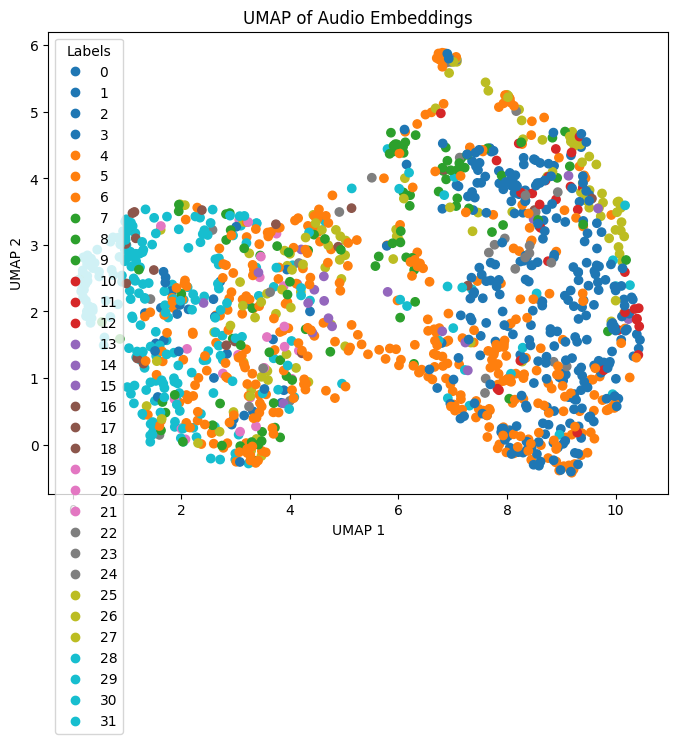

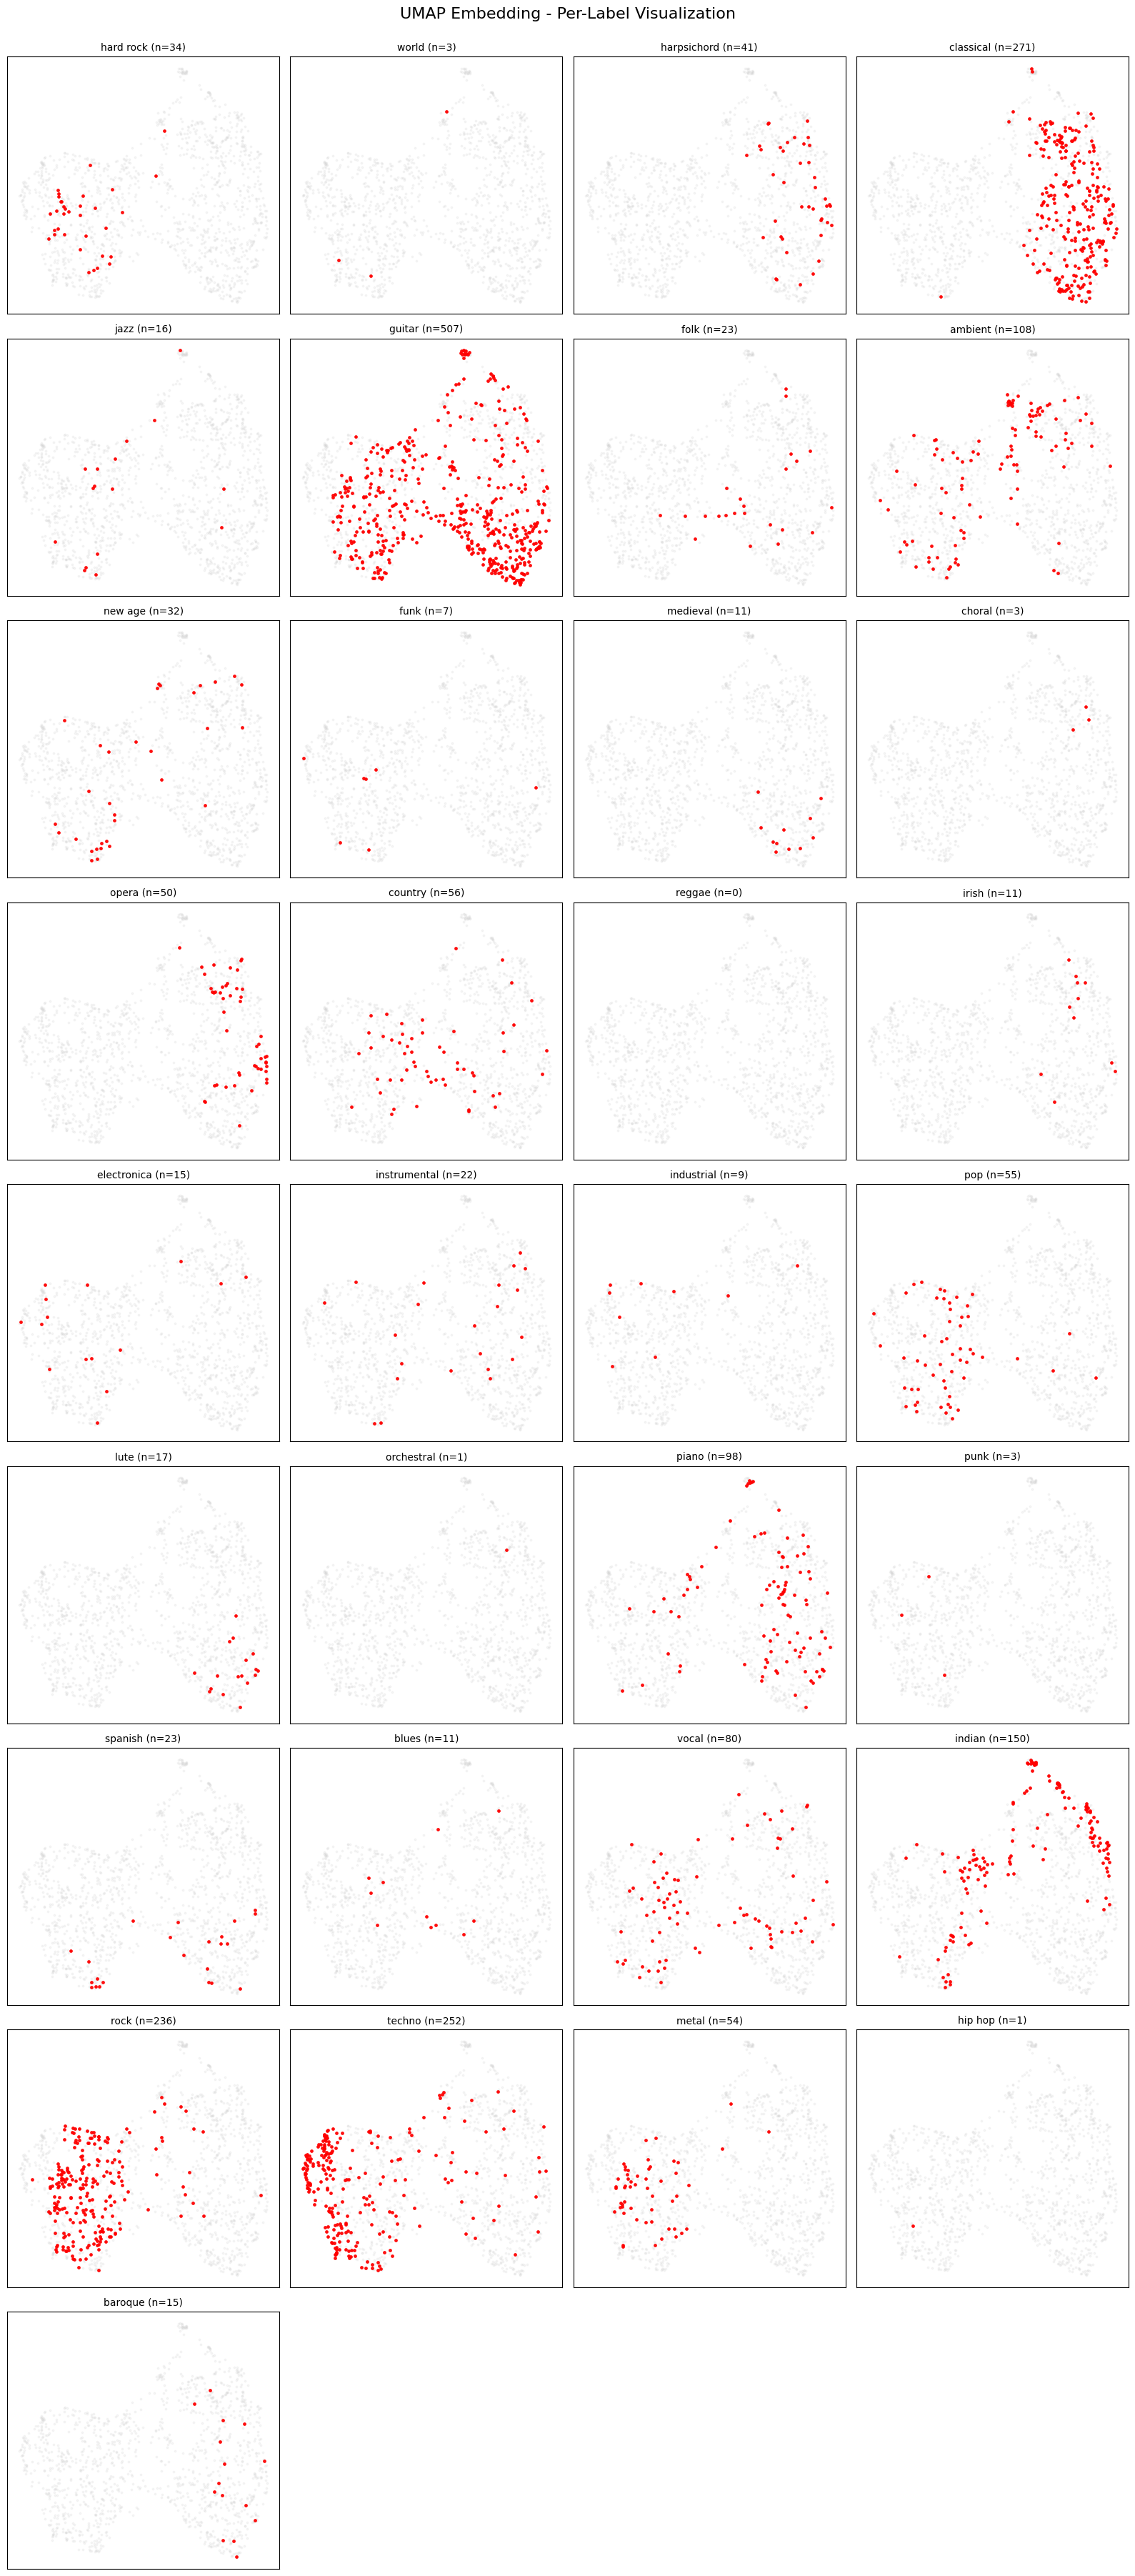

In [24]:
cnn_tl = CNN(dense_size=64, output_size=64).to(device)
checkpoint_path = "checkpoints/cnn_tl.pt"

print("\nTraining model with the triplet loss")
train(cnn_tl, triplet_loss, n_epochs=20, device=device, batch_size=64,checkpoint_path=checkpoint_path)
plot_val_embeddings(cnn_tl, device=device)


Training model with the InfoNCE loss
Epoch [1/20], Train loss: 3.5831, Val loss: 3.5685
  ➤ New best model saved to checkpoints/cnn_infonce.pt
Epoch [2/20], Train loss: 3.3181, Val loss: 3.4014
  ➤ New best model saved to checkpoints/cnn_infonce.pt
Epoch [3/20], Train loss: 3.2076, Val loss: 3.3072
  ➤ New best model saved to checkpoints/cnn_infonce.pt
Epoch [4/20], Train loss: 3.1504, Val loss: 3.2520
  ➤ New best model saved to checkpoints/cnn_infonce.pt
Epoch [5/20], Train loss: 3.1168, Val loss: 3.2634
  Patience: 1/5
Epoch [6/20], Train loss: 3.0883, Val loss: 3.2258
  ➤ New best model saved to checkpoints/cnn_infonce.pt
Epoch [7/20], Train loss: 3.0640, Val loss: 3.3271
  Patience: 1/5
Epoch [8/20], Train loss: 3.0627, Val loss: 3.2490
  Patience: 2/5
Epoch [9/20], Train loss: 3.0394, Val loss: 3.1890
  ➤ New best model saved to checkpoints/cnn_infonce.pt
Epoch [10/20], Train loss: 3.0204, Val loss: 3.2060
  Patience: 1/5
Epoch [11/20], Train loss: 3.0221, Val loss: 3.1424
  ➤ N

/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venvpy311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embeddings shape: (1337, 2)


/var/folders/r4/z65_5ryn59z3_3lyzgvxdcm40000gn/T/ipykernel_92956/1946034281.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap("tab10", len(unique_labels))


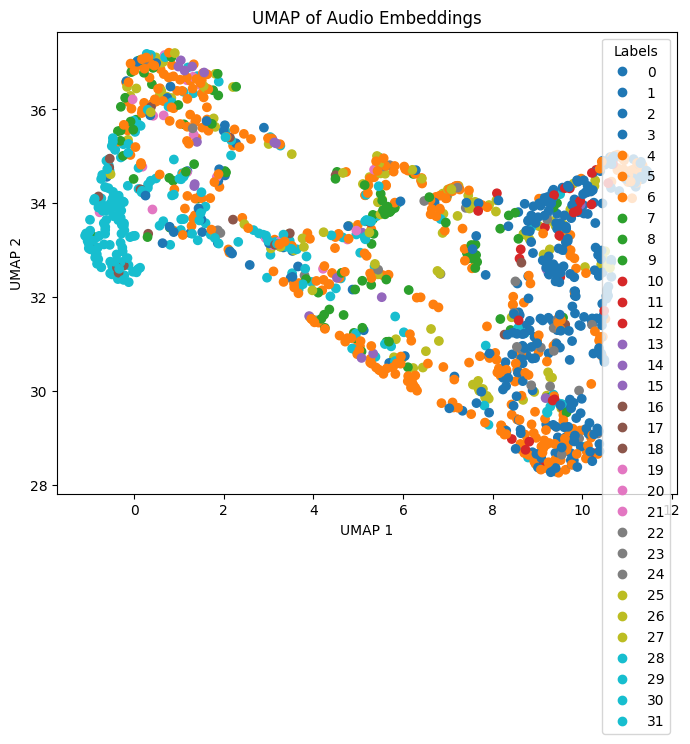

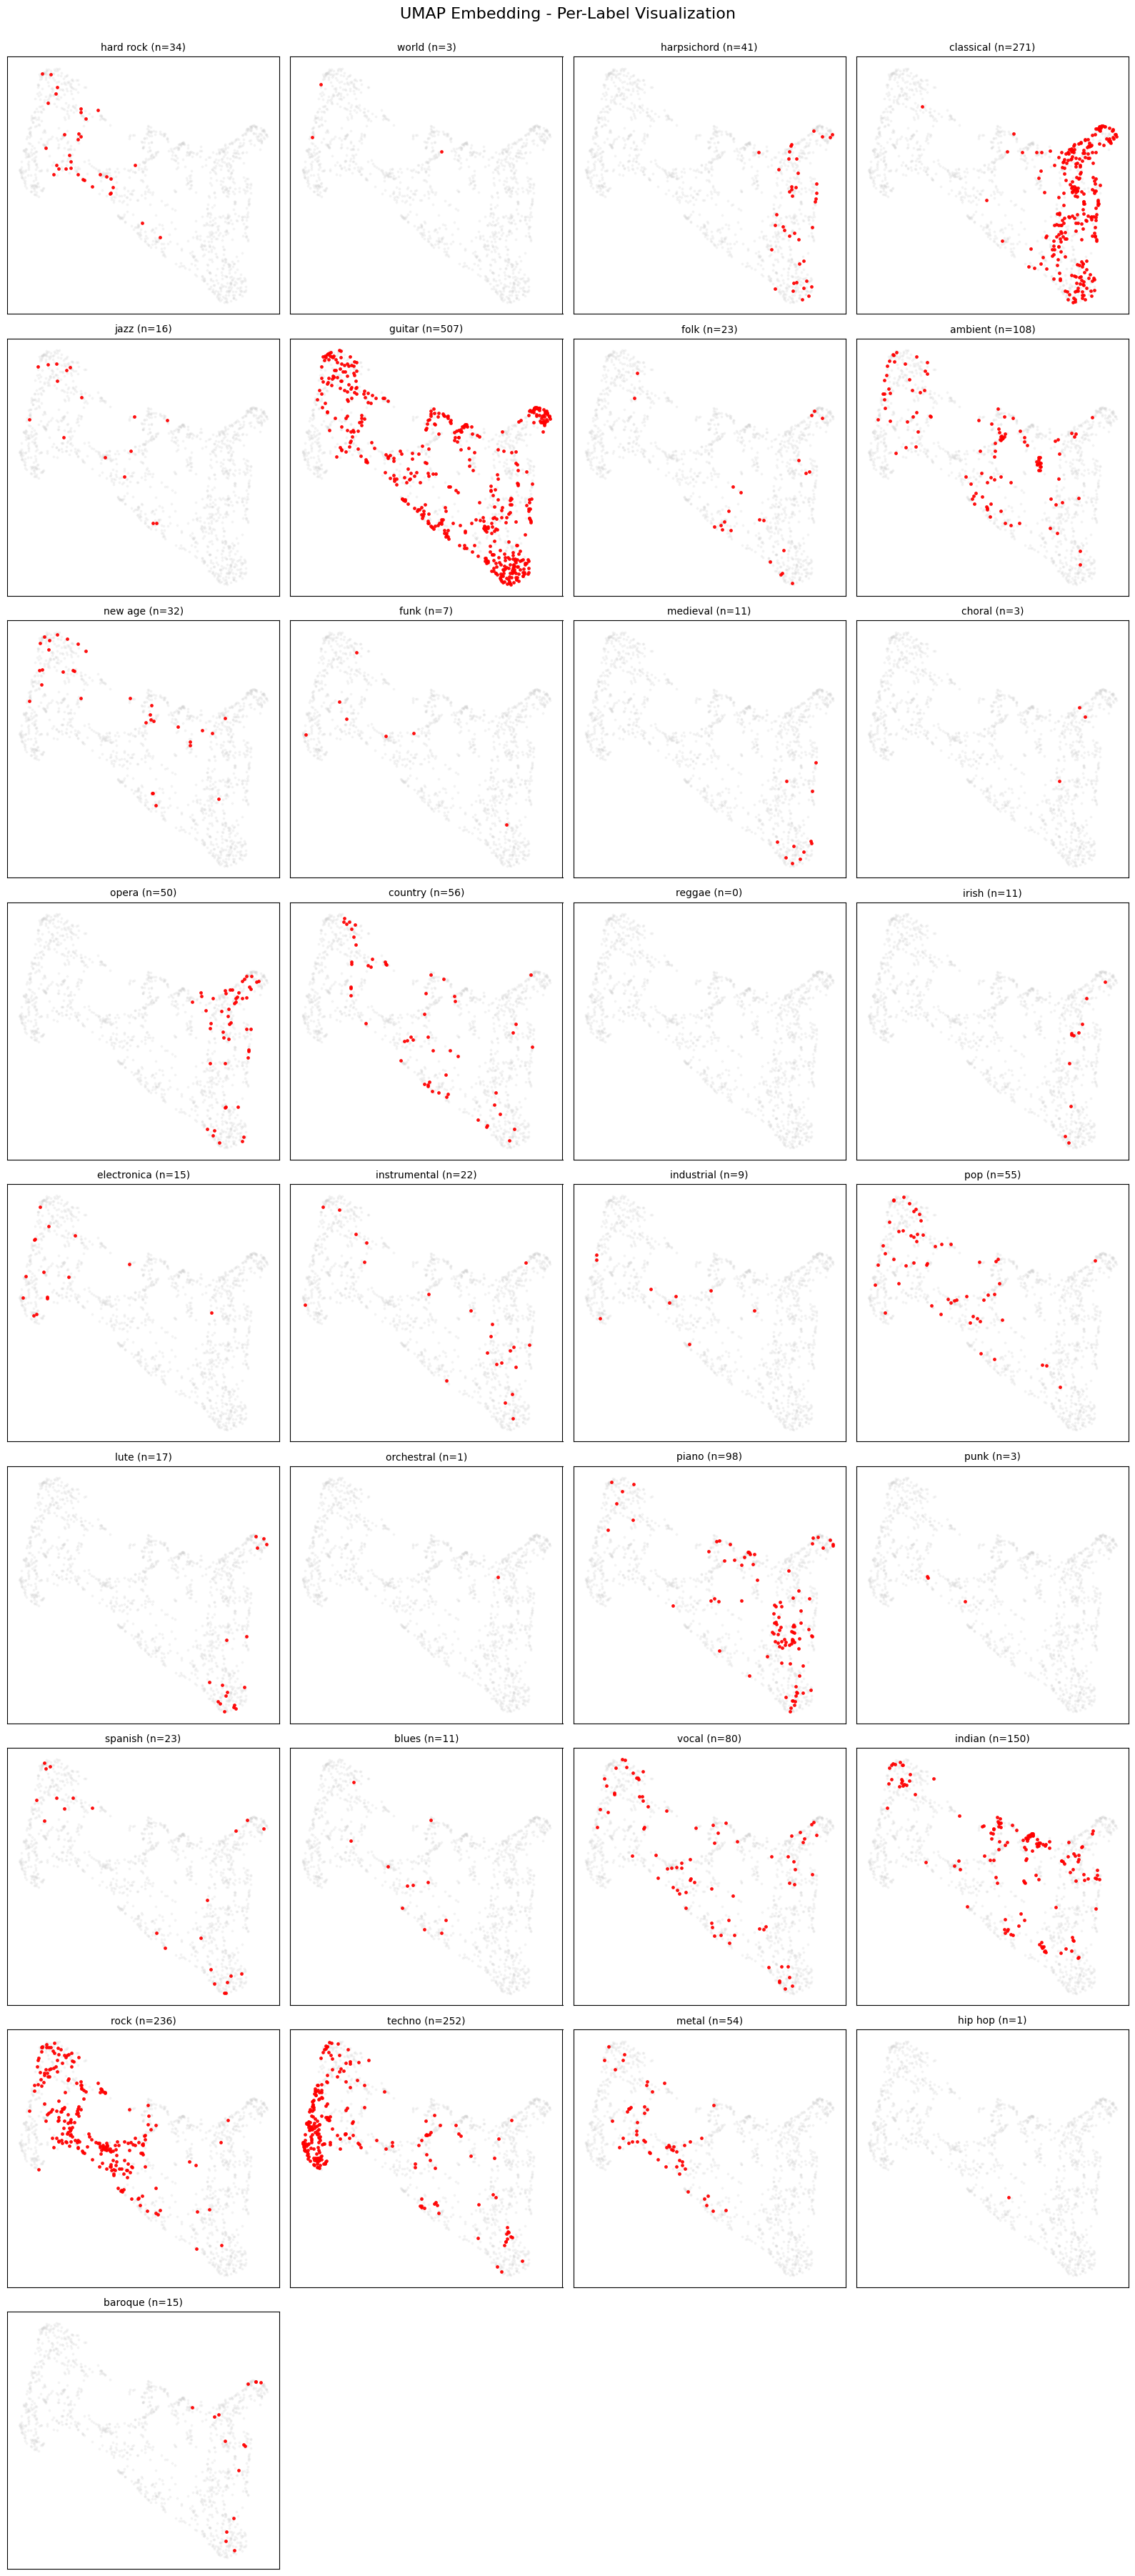

In [25]:
cnn = CNN(dense_size=64, output_size=64).to(device)
checkpoint_path = "checkpoints/cnn_infonce.pt"

print("\nTraining model with the InfoNCE loss")
train(cnn, InfoNCE, n_epochs=20, device=device, batch_size=64, checkpoint_path=checkpoint_path)
plot_val_embeddings(cnn, device=device)

## Plot 2: Hard Rock vs. World


In [26]:
def plot_val_embeddings_2(model, device="cuda"):
    model.eval()
    embeddings = []
    natural_labels = []

    model.to(device)
    feature_extractor.to(device)
    
    with torch.no_grad():
        for batch in val_loader:
            audio_1 = batch["view_1"].to(device)
            labels = batch["labels"].to(device)

            x = feature_extractor(audio_1)
            z = model(x)
            embeddings.append(z.cpu().numpy())
            natural_labels.append(labels.cpu().numpy())

    embeddings = np.concatenate(embeddings, axis=0)
    Y = np.concatenate(natural_labels, axis=0)
    label_names = annotations.columns[1:-2]

    # --------------------------------------------
    # Find 2 labels whose datapoints NEVER overlap
    # --------------------------------------------
    num_labels = Y.shape[1]
    chosen_pair = None

    for i in range(num_labels):
        for j in range(i + 1, num_labels):
            overlap = np.logical_and(Y[:, i] == 1, Y[:, j] == 1).sum()
            if overlap == 0:
                chosen_pair = (i, j)
                break
        if chosen_pair:
            break

    if chosen_pair is None:
        print("No pair of non-overlapping genres found!")
        return

    idx_a, idx_b = chosen_pair
    print(f"Selected non-overlapping genres: {label_names[idx_a]} & {label_names[idx_b]}")

    # --------------------------------------------
    # UMAP Embedding
    # --------------------------------------------
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=25,
        min_dist=0.1,
        metric='euclidean',
        random_state=42
    )
    umap_embeddings = reducer.fit_transform(embeddings)

    # --------------------------------------------
    # Plot everything faintly, highlight the 2 genres
    # --------------------------------------------
    plt.figure(figsize=(9, 7))

    # Base scatter (all samples, light)
    plt.scatter(
        umap_embeddings[:, 0], umap_embeddings[:, 1],
        c="lightgray", s=5, alpha=0.3, label="Other samples"
    )

    # Genre A (highlight)
    mask_a = Y[:, idx_a].astype(bool)
    plt.scatter(
        umap_embeddings[mask_a, 0], umap_embeddings[mask_a, 1],
        c="blue", s=25, alpha=0.9, label=f"{label_names[idx_a]}"
    )

    # Genre B (highlight)
    mask_b = Y[:, idx_b].astype(bool)
    plt.scatter(
        umap_embeddings[mask_b, 0], umap_embeddings[mask_b, 1],
        c="red", s=25, alpha=0.9, label=f"{label_names[idx_b]}"
    )

    plt.title(
        f"UMAP – Highlighting 2 Non-Overlapping Genres:\n"
        f"{label_names[idx_a]} (blue) vs {label_names[idx_b]} (red)"
    )
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.legend()
    plt.show()


CNN Baseline UMAP
Selected non-overlapping genres: hard rock & world


/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venvpy311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


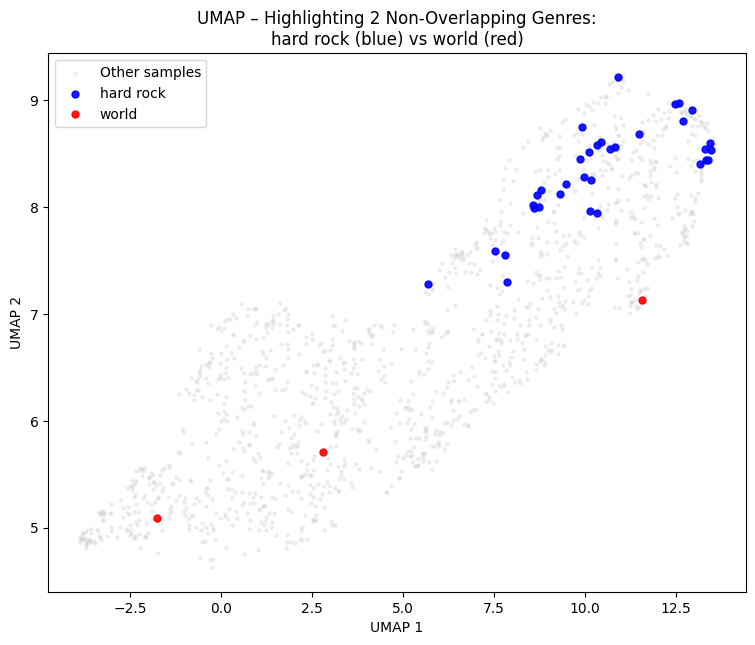

CNN Triplet Loss UMAP
Selected non-overlapping genres: hard rock & world


/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venvpy311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


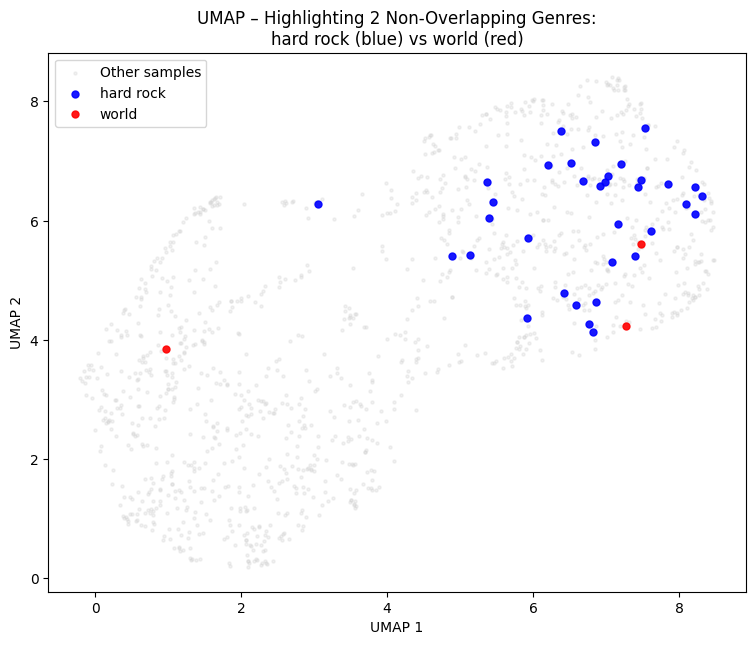

CNN InfoNCE Loss UMAP
Selected non-overlapping genres: hard rock & world


/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venvpy311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


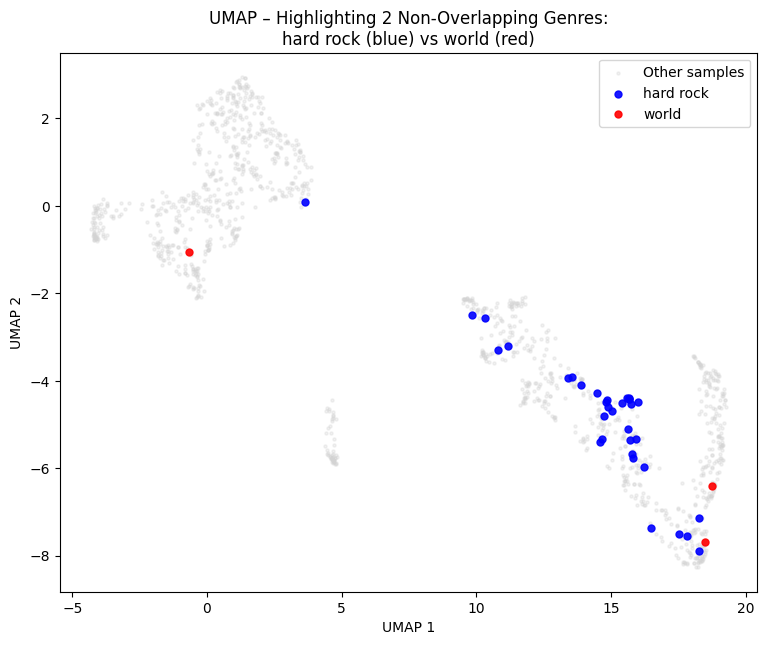

In [29]:
print("CNN Baseline UMAP")
plot_val_embeddings_2(cnn_baseline, device=device)

print("CNN Triplet Loss UMAP")
plot_val_embeddings_2(cnn_tl, device=device)

print("CNN InfoNCE Loss UMAP")
plot_val_embeddings_2(cnn, device=device)

## Plot 3: Multi-Genre Comparison

In [33]:
def plot_val_embeddings_3(model, device="cuda"):
    model.eval()
    embeddings = []
    natural_labels = []

    model.to(device)
    feature_extractor.to(device)
    
    with torch.no_grad():
        for batch in val_loader:
            audio_1 = batch["view_1"].to(device)
            labels = batch["labels"].to(device)

            x = feature_extractor(audio_1)
            z = model(x)
            embeddings.append(z.cpu().numpy())
            natural_labels.append(labels.cpu().numpy())

    embeddings = np.concatenate(embeddings, axis=0)
    Y = np.concatenate(natural_labels, axis=0)
    label_names = annotations.columns[1:-2]

    # ----------------------------------------------------------------------
    # Find a maximal set of labels that never co-occur (no overlapping datapoints)
    # ----------------------------------------------------------------------

    num_labels = Y.shape[1]

    # Build overlap matrix: overlap[i,j] = True if labels i and j ever co-occur
    overlap_matrix = np.zeros((num_labels, num_labels), dtype=bool)

    for i in range(num_labels):
        for j in range(i + 1, num_labels):
            overlap = np.logical_and(Y[:, i] == 1, Y[:, j] == 1).sum() > 0
            overlap_matrix[i, j] = overlap
            overlap_matrix[j, i] = overlap

    # Greedy maximal independent set (MIS)
    available = set(range(num_labels))
    non_overlapping_group = []

    while available:
        # Pick a label with the fewest overlaps (good heuristic)
        label = min(
            available,
            key=lambda x: overlap_matrix[x].sum()
        )
        non_overlapping_group.append(label)

        # Remove the label AND all labels that overlap with it
        to_remove = {i for i in available if overlap_matrix[label, i]}
        available = available - to_remove - {label}

    group_names = [label_names[i] for i in non_overlapping_group]
    print(f"Found non-overlapping label group (size {len(non_overlapping_group)}):")
    print(group_names)


    # --------------------------------------------
    # UMAP Embedding
    # --------------------------------------------
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=25,
        min_dist=0.1,
        metric='euclidean',
        random_state=42
    )
    umap_embeddings = reducer.fit_transform(embeddings)

    # ----------------------------------------------------------------------
    # Plot all points faintly, then highlight all chosen labels
    # ----------------------------------------------------------------------

    plt.figure(figsize=(10, 8))

    # Background (all points)
    plt.scatter(
        umap_embeddings[:, 0], umap_embeddings[:, 1],
        c="lightgray", s=5, alpha=0.25, label="Other samples"
    )

    colors = matplotlib.cm.get_cmap("tab10", len(non_overlapping_group))

    for idx, label_idx in enumerate(non_overlapping_group):
        mask = Y[:, label_idx].astype(bool)

        plt.scatter(
            umap_embeddings[mask, 0],
            umap_embeddings[mask, 1],
            s=30,
            alpha=0.9,
            c=[colors(idx)],
            label=label_names[label_idx]
        )

    plt.title(
        f"UMAP – Group of {len(non_overlapping_group)} Non-Overlapping Genres"
    )
    plt.legend()
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.show()



In [42]:
checkpoint = torch.load("checkpoints/cnn_tl.pt", map_location=device,weights_only=False)

cnn_tl = CNN(dense_size=64, output_size=64).to(device)
cnn_tl.load_state_dict(checkpoint)
cnn_tl.to(device)

checkpoint = torch.load("checkpoints/cnn_infonce.pt", map_location=device,weights_only=False)

cnn = CNN(dense_size=64, output_size=64).to(device)
cnn.load_state_dict(checkpoint)
cnn.to(device)

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
)

CNN Baseline UMAP
Found non-overlapping label group (size 13):
['reggae', 'hip hop', 'choral', 'orchestral', 'punk', 'industrial', 'hard rock', 'irish', 'electronica', 'blues', 'baroque', 'world', 'spanish']


/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venvpy311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/r4/z65_5ryn59z3_3lyzgvxdcm40000gn/T/ipykernel_4270/4178529336.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = matplotlib.cm.get_cmap("tab10", len(non_overlapping_group))


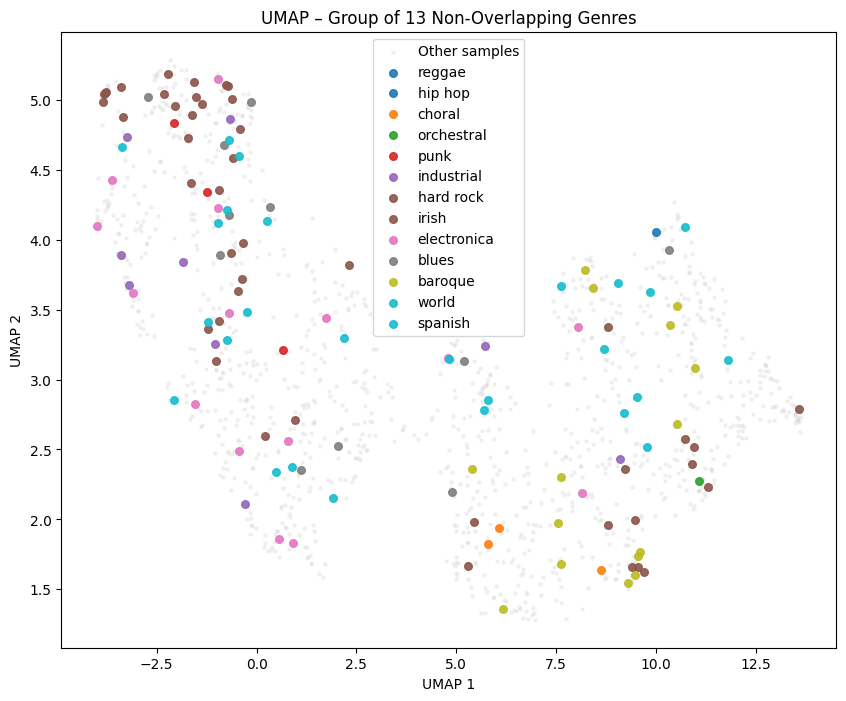

CNN Triplet Loss UMAP
Found non-overlapping label group (size 13):
['reggae', 'hip hop', 'choral', 'orchestral', 'punk', 'industrial', 'hard rock', 'irish', 'electronica', 'blues', 'baroque', 'world', 'spanish']


/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venvpy311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/r4/z65_5ryn59z3_3lyzgvxdcm40000gn/T/ipykernel_4270/4178529336.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = matplotlib.cm.get_cmap("tab10", len(non_overlapping_group))


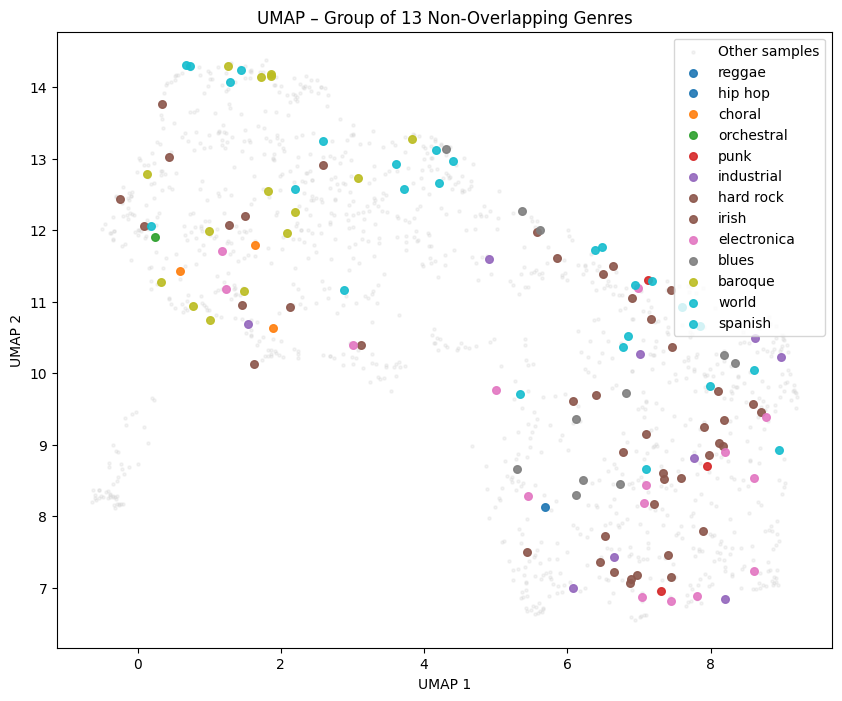

CNN InfoNCE Loss UMAP
Found non-overlapping label group (size 13):
['reggae', 'hip hop', 'choral', 'orchestral', 'punk', 'industrial', 'hard rock', 'irish', 'electronica', 'blues', 'baroque', 'world', 'spanish']


/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venvpy311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/r4/z65_5ryn59z3_3lyzgvxdcm40000gn/T/ipykernel_4270/4178529336.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = matplotlib.cm.get_cmap("tab10", len(non_overlapping_group))


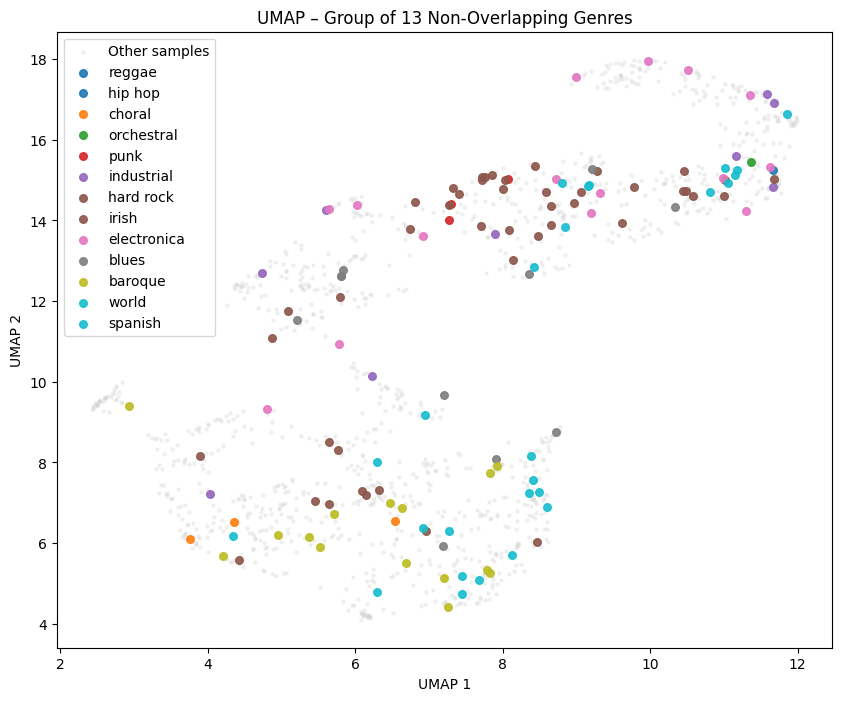

In [43]:
print("CNN Baseline UMAP")
plot_val_embeddings_3(cnn_baseline, device=device)

print("CNN Triplet Loss UMAP")
plot_val_embeddings_3(cnn_tl, device=device)

print("CNN InfoNCE Loss UMAP")
plot_val_embeddings_3(cnn, device=device)